In [1]:
import pickle
import os
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as scp
from scipy.stats import ranksums
import gzip
import scipy.stats as scp
from statsmodels.stats.multitest import multipletests

In [31]:
hippiedata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/hippie/"
genelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/"
hisigdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/hisig/"
UCSCtoilpath="/home/ajayasha/scratch/Arvind_umd/UCSC-TOIL/"
ECMprojpath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/"
RCDprojpath="/home/ajayasha/scratch/Arvind_umd/RCD/"
GDCPANCANpath="/home/ajayasha/scratch/Arvind_umd/GDC-PANCAN/"
subtypepath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/subtype_purity/ecm_subtypes/"
figpath=ECMprojpath+"Figures/"

In [3]:
ecm_subtypes=pd.read_csv(subtypepath+"annotation-tcga.tsv",sep="\t",index_col=0)

In [4]:
ecm_subtypes

,TCGA_project,HISTOLOGICAL_SUBTYPE,Gender,Age,P_stage,C_stage,MFP,Immune Subtype,TCGA Subtype,OS,...,MSI,EBV,HBV,HCV,HPV,Smoking,Race,Ethnicity,histological_type,icd_o_3_histology
TCGA-OR-A5J1,ACC,ACC,M,58.0,I/II,NaN,IE,C4,ACC.CIMP-high,1355.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,NaN,Adrenocortical carcinoma- Usual Type,8370/1
TCGA-OR-A5J2,ACC,ACC,F,44.0,III/IV,NaN,F,C3,ACC.CIMP-low,1677.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,HISPANIC OR LATINO,Adrenocortical carcinoma- Usual Type,8370/3
TCGA-OR-A5J3,ACC,ACC,F,23.0,III/IV,NaN,D,C4,ACC.CIMP-intermediate,2091.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,HISPANIC OR LATINO,Adrenocortical carcinoma- Usual Type,8370/3
TCGA-OR-A5J5,ACC,ACC,M,30.0,III/IV,NaN,D,C4,ACC.CIMP-intermediate,365.0,...,MSI,NaN,NaN,NaN,NaN,NaN,WHITE,HISPANIC OR LATINO,Adrenocortical carcinoma- Usual Type,8370/3
TCGA-OR-A5J6,ACC,ACC,F,29.0,I/II,NaN,IE,C4,ACC.CIMP-low,2703.0,...,MSS,NaN,NaN,NaN,NaN,NaN,BLACK OR AFRICAN AMERICAN,HISPANIC OR LATINO,Adrenocortical carcinoma- Usual Type,8370/3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-YZ-A980,UVM,UVM,M,75.0,III/IV,III/IV,F,C3,NaN,1862.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,NOT HISPANIC OR LATINO,Uveal melanoma,8770/3
TCGA-YZ-A982,UVM,UVM,F,79.0,III/IV,III/IV,D,C5,NaN,495.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,NOT HISPANIC OR LATINO,Uveal melanoma,8772/3
TCGA-YZ-A983,UVM,UVM,F,51.0,I/II,I/II,IE,C4,NaN,798.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,NOT HISPANIC OR LATINO,Uveal melanoma,8771/3
TCGA-YZ-A984,UVM,UVM,F,50.0,I/II,III/IV,F,C3,NaN,1396.0,...,MSS,NaN,NaN,NaN,NaN,NaN,WHITE,NOT HISPANIC OR LATINO,Uveal melanoma,8770/3


In [5]:
ecm_subtypes.columns

Index(['TCGA_project', 'HISTOLOGICAL_SUBTYPE', 'Gender', 'Age', 'P_stage',
       'C_stage', 'MFP', 'Immune Subtype', 'TCGA Subtype', 'OS', 'OS_FLAG',
       'PFS', 'PFS_Flag', 'ips_ctla4_neg_pd1_neg', 'ips_ctla4_neg_pd1_pos',
       'ips_ctla4_pos_pd1_neg', 'ips_ctla4_pos_pd1_pos', 'Purity', 'TMB',
       'BCR Evenness', 'BCR Shannon', 'BCR Richness', 'TCR Shannon',
       'TCR Richness', 'TCR Evenness', 'Margin_status', 'Residual_Tumor',
       'MSI', 'EBV', 'HBV', 'HCV', 'HPV', 'Smoking', 'Race', 'Ethnicity',
       'histological_type', 'icd_o_3_histology'],
      dtype='object')

In [6]:
ecm_subtypes["TCGA_project"].unique()

array(['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'READ', 'ESCA',
       'STAD', 'HNSC', 'KICH', 'KIRC', 'KIRP', 'LIHC', 'LUAD', 'LUSC',
       'OV', 'PAAD', 'PCPG', 'PRAD', 'SKCM', 'THCA', 'UCEC', 'UCS', 'UVM'],
      dtype=object)

In [7]:
ecm_subtypes.index=ecm_subtypes.index.to_series().apply(lambda x: x.replace("-",".")).values.tolist()
ecm_subtypes.index.name="sampid"

In [8]:
ecmsubtype_grp=ecm_subtypes.reset_index().groupby(["TCGA_project","MFP"]).agg({"sampid":list})

In [9]:
#ecmsubtype_grp[ecmsubtype_grp.index.get_level_values(0)=="OV"]
test=[]
for g in ecmsubtype_grp[ecmsubtype_grp.index.get_level_values(0)=="OV"].index:
    test+=ecmsubtype_grp[ecmsubtype_grp.index.get_level_values(0)=="OV"].loc[g,'sampid']
len(test)

416

In [10]:
ecm_sig=pd.read_csv(subtypepath+"signatures-tcga.tsv",sep="\t",index_col=0)

In [11]:
ecm_sig

,TCGA-OR-A5J1,TCGA-OR-A5J2,TCGA-OR-A5J3,TCGA-OR-A5J5,TCGA-OR-A5J6,TCGA-OR-A5J7,TCGA-OR-A5J8,TCGA-OR-A5J9,TCGA-OR-A5JA,TCGA-OR-A5JB,...,TCGA-WC-A885,TCGA-WC-A888,TCGA-WC-A88A,TCGA-WC-AA9A,TCGA-WC-AA9E,TCGA-YZ-A980,TCGA-YZ-A982,TCGA-YZ-A983,TCGA-YZ-A984,TCGA-YZ-A985
Angiogenesis,-0.661531,1.583381,0.267748,-2.647846,-0.071126,1.362581,2.838784,2.524522,-0.402077,-1.257830,...,-1.574175,-1.307615,1.649727,-1.279347,-1.740467,1.294947,-1.316592,-0.879181,2.475212,0.113487
Endothelium,-0.474094,1.424070,-1.519066,-2.290573,1.212545,1.006049,-0.009537,1.579478,-1.519467,-2.714505,...,-1.287016,-0.667840,1.465586,-2.173068,-1.552286,1.606122,0.037654,-0.240127,2.836803,0.293002
CAF,-1.747577,0.954718,-0.533190,-0.559493,-1.912118,-0.273307,4.000000,-0.430856,0.203419,1.195279,...,-0.673280,-0.344506,0.807490,-2.668342,-1.404025,0.623299,0.301762,-1.820833,1.391151,0.196909
Matrix,-2.182482,0.165168,-0.546502,-0.956463,-2.032676,0.233766,2.127843,-0.855926,0.426424,0.729188,...,-1.303162,-0.453696,1.447741,-2.233778,-0.981243,0.939589,-0.988046,-1.742297,0.800888,0.559041
Matrix_remodeling,-1.236812,-0.229481,2.180185,0.133336,-1.325297,-1.288253,4.000000,-0.874358,1.693402,3.615724,...,0.726274,1.286900,1.821143,-0.393247,-0.566016,-0.328423,1.236542,-0.442878,0.397429,0.236518
Protumor_cytokines,0.046394,0.749703,-0.834455,0.354727,-0.393967,-0.857028,4.000000,2.120170,0.110579,4.000000,...,-0.977007,0.196846,-0.522635,-2.175384,-2.263368,-0.160317,1.865904,-1.645667,0.644433,1.297071
Neutrophil_signature,-1.316791,-0.548288,-0.349687,0.996735,-1.371924,-0.374230,0.921043,0.206068,0.215364,2.028717,...,2.183762,-0.279102,0.951835,0.688095,-1.580825,-2.716089,-0.422485,-0.894061,1.046496,2.979998
Granulocyte_traffic,-0.521001,-0.404893,-0.025436,-1.391741,-0.282401,0.402515,4.000000,-0.741854,0.045573,4.000000,...,2.678470,2.105397,1.304707,-1.208721,-1.120801,-2.752239,-0.323674,0.281776,-0.189720,-0.032744
Macrophages,0.037743,0.000000,-0.827868,-1.056910,2.007733,-1.279000,3.820800,-1.617280,-0.301448,2.099384,...,-1.861050,2.126701,0.455610,-2.176778,-0.606343,-0.577582,0.810570,-0.176896,-0.063765,0.621391
Macrophage_DC_traffic,-0.490876,0.537373,-1.067597,-1.822861,1.326364,-0.983067,3.365641,-1.395602,-0.867141,2.021117,...,-0.663788,2.676467,-0.201871,-2.020546,-1.116551,-0.201602,-0.741519,-0.313016,0.439604,0.130049


In [12]:
tcganatgtex=pd.read_csv(ECMprojpath+"tcganatgtex.txt",sep="\t",index_col=0)
tcganatgtex.dropna(how='all',subset=["NAT","GTEX"],inplace=True)
tcganatgtex

,Cancer,NAT,GTEX
TARGET-ALL1,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-ALL2,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-ALL3,Acute Lymphoblastic Leukemia_White blood cell_...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML1,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,Whole Blood_Blood_Normal Tissue
TCGA-LAML,Acute Myeloid Leukemia_White blood cell_Primar...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML2,Acute Myeloid Leukemia_White blood cell_Recurr...,NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML3,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,Whole Blood_Blood_Normal Tissue
TARGET-AML4,"Acute Myeloid Leukemia, Induction Failure Subp...",NaN,Whole Blood_Blood_Normal Tissue
TCGA-ACC,Adrenocortical Cancer_Adrenal gland_Primary Tumor,NaN,Adrenal Gland_Adrenal Gland_Normal Tissue
TCGA-BLCA,Bladder Urothelial Carcinoma_Bladder_Primary T...,Bladder Urothelial Carcinoma_Bladder_Solid Tis...,NaN


In [13]:
tcganatgtex_dict=tcganatgtex.to_dict()
combgenexfiles={}
for ctype in tcganatgtex_dict:
    for proj in tcganatgtex_dict[ctype]:
        if proj not in combgenexfiles:
            combgenexfiles[proj]=[]
        try:
            for file in tcganatgtex_dict[ctype][proj].split(","):
                combgenexfiles[proj].append(file)
        except:
            pass
combgenexfiles

{'TARGET-ALL1': ['Acute Lymphoblastic Leukemia_White blood cell_Primary Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-ALL2': ['Acute Lymphoblastic Leukemia_White blood cell_Primary Blood Derived Cancer - Peripheral Blood',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-ALL3': ['Acute Lymphoblastic Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML1': ['Acute Myeloid Leukemia_White blood cell_Primary Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TCGA-LAML': ['Acute Myeloid Leukemia_White blood cell_Primary Blood Derived Cancer - Peripheral Blood',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML2': ['Acute Myeloid Leukemia_White blood cell_Recurrent Blood Derived Cancer - Bone Marrow',
  'Whole Blood_Blood_Normal Tissue'],
 'TARGET-AML3': ['Acute Myeloid Leukemia',
  ' Induction Failure Subproject_White blood cell_Post treatment Blood Cancer - B

In [14]:
inv_combgenex={}
for ct in combgenexfiles:
    for file in combgenexfiles[ct]:
        inv_combgenex[file]=ct
sthued={}
for ct in inv_combgenex:
    if "_Primary Tumor" in ct:
        sthued[ct]="PT"
    elif "_Solid Tissue Normal" in ct:
        sthued[ct]="NAT"
    elif "_Metastatic" in ct:
        sthued[ct]="MT"
    elif "_Recurrent" in ct:
        sthued[ct]="RT"
    elif "Cancer" in ct:
        sthued[ct]="PT"
    else:
        sthued[ct]="GTEX"

In [15]:
realsupmod_ecm=pd.read_pickle("../supmod_scores.pkl")

In [16]:
rev_realsupmod_ecm=realsupmod_ecm[realsupmod_ecm.columns[realsupmod_ecm.columns.get_level_values(1).isin(["PT","MT"])]].copy()

In [17]:
rev_realsupmod_ecm=rev_realsupmod_ecm.droplevel(level=[0,1,2],axis=1)

In [18]:
samlist=[".".join(x.split(".")[0:3]) for x in rev_realsupmod_ecm.columns]
rev_realsupmod_ecm.columns=samlist
rev_realsupmod_ecm

,TARGET.10.PAPBZK,TARGET.10.PANJPG,TARGET.10.PARBRK,TARGET.10.PARPNM,TARGET.10.PASUBW,TARGET.10.PAPDUV,TARGET.10.PAPZNK,TARGET.10.PAPHJF,TARGET.10.PAPJHR,TARGET.10.PAMXSP,...,TCGA.BG.A3EW,TCGA.EO.A3KW,TCGA.B5.A0JR,TCGA.FI.A3PX,TCGA.DI.A1C3,TCGA.PG.A7D5,TCGA.EO.A3AZ,TCGA.B5.A11R,TCGA.B5.A3S1,TCGA.FI.A2EY
module_0,-0.445273,-0.411924,-0.327045,-0.427968,-0.358715,-0.328144,-0.404147,-0.465367,-0.241776,-0.376749,...,-0.205920,0.207769,-0.197434,-0.242147,0.299556,0.210483,0.096656,-0.278552,0.153603,0.205801
module_2,-0.214254,0.279019,0.206723,0.187041,-0.202859,0.253946,0.232516,0.384009,0.342885,0.276158,...,0.210654,-0.196932,-0.126193,0.162663,-0.180599,0.203514,-0.320923,-0.202529,0.172141,-0.247302
module_3,-0.350052,-0.327195,-0.332890,-0.315828,-0.341384,-0.268840,-0.306294,-0.340276,0.229678,-0.329651,...,0.273752,0.186240,-0.136398,-0.256143,0.292388,0.190633,-0.187178,-0.266400,0.152114,0.226952
module_4,0.217438,0.311207,0.249882,-0.202634,-0.235340,0.289899,0.219214,0.340592,0.388386,0.305270,...,0.171118,-0.184602,0.157406,-0.154227,0.173171,0.191601,-0.332822,-0.204585,-0.160713,-0.241353
module_5,-0.282936,-0.237554,-0.205661,-0.273442,-0.292069,-0.207508,-0.244546,-0.235868,0.268269,0.212927,...,-0.165486,-0.227194,-0.170972,-0.170413,0.144841,0.163455,-0.340649,-0.267115,-0.133575,-0.207211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
module_228,-0.240056,0.230847,0.300532,0.317005,0.280522,0.347213,0.289964,0.348784,0.513511,0.278530,...,-0.188002,-0.204813,-0.170675,0.182944,0.297789,0.244837,-0.380195,-0.221509,0.194786,-0.219088
module_230,-0.280827,-0.418977,-0.413035,-0.314118,-0.430592,-0.378122,-0.351572,-0.356115,0.293073,-0.353354,...,0.338020,-0.282132,0.245949,0.261374,0.186609,0.336110,0.244693,0.246290,0.342343,-0.220133
module_231,0.322981,-0.295689,-0.200451,-0.311898,-0.380299,-0.267219,-0.448922,-0.210698,-0.441586,-0.285560,...,0.316673,0.474067,0.569312,0.380967,0.432760,0.594969,0.479886,0.577799,0.355866,0.448676
module_232,-0.416799,-0.477073,-0.325890,-0.504981,-0.501128,-0.400661,-0.485571,-0.503185,-0.291314,-0.358249,...,-0.205911,-0.275593,-0.234413,-0.327989,0.297871,0.122220,0.115214,-0.382968,-0.194094,0.229105


In [19]:
def compare_ssgsea_scores(ssgsea_df, groups_df):
    """
    Performs a Wilcoxon rank-sum test to compare ssGSEA scores for each group against the rest.

    Args:
        ssgsea_df (pd.DataFrame): DataFrame with gene sets as rows and samples as columns,
                                  containing ssGSEA enrichment scores.
        groups_df (pd.DataFrame): DataFrame with group names as the index and a column
                                  named 'sample_ids' containing lists of sample IDs.

    Returns:
        pd.DataFrame: A DataFrame containing the p-value and U-statistic for each
                      gene set and each group comparison.
    """
    results = []
    all_samples=[]
    for group in groups_df.index: 
            # --- Data Selection ---
            # Get the sample names for the current group from the input dataframe
            all_samples += groups_df.loc[group,"sampid"]
    all_samples = set(all_samples)
    # Iterate over each gene set in the ssGSEA score dataframe
    for gene_set in ssgsea_df.index:
        
        # Iterate over each unique group to perform the comparison
        for group in groups_df.index:
            
            # --- Data Selection ---
            # Get the sample names for the current group from the input dataframe
            group_samples = groups_df.loc[group,"sampid"]
            
            # Get the sample names for all other groups (the "rest")
            rest_samples = list(all_samples - set(group_samples))

            # Select the ssGSEA scores for the current group
            group_scores = ssgsea_df.loc[gene_set, ssgsea_df.columns.intersection(group_samples)]
            
            # Select the ssGSEA scores for the rest of the samples
            rest_scores = ssgsea_df.loc[gene_set, ssgsea_df.columns.intersection(rest_samples)]

            # --- Wilcoxon Rank-Sum Test ---
            # Check if both groups have data to avoid errors
            if not group_scores.empty and not rest_scores.empty:
                # The ranksums function returns the U-statistic and the two-sided p-value
                u_statistic, p_value = ranksums(group_scores, rest_scores,alternative='greater')
                mean_difference = group_scores.mean() - rest_scores.mean()

                results.append({
                    'gene_set': gene_set,
                    'group': group,
                    'u_statistic': u_statistic,
                    'p_value': p_value,
                    'mean_difference': mean_difference
                })
    if not results:
        # Return an empty DataFrame if no tests were performed
        return pd.DataFrame()

    # Convert the list of dictionaries to a pandas DataFrame
    results_df = pd.DataFrame(results)
    results_df.set_index(['group','gene_set'],inplace=True)
    # Step 2: Apply multiple testing correction (Benjamini/Hochberg FDR)
    # The correction is applied to all p-values calculated across all tests.
    reject, pvals_corrected, _, _ = multipletests(
        results_df['p_value'], 
        alpha=0.05, 
        method='fdr_bh'
    )
    
    results_df['p_value_adjusted'] = pvals_corrected
    return results_df

In [21]:
testres={}
for proj in ecmsubtype_grp.index.get_level_values(0).unique():
    testres[proj]=compare_ssgsea_scores(rev_realsupmod_ecm,ecmsubtype_grp.loc[proj])

In [22]:
revtestres={}
for proj in testres:
    revtestres[proj]={}
    for subt in ['IE/F','F','D','IE']:
        try:
            revtestres[proj][subt]=testres[proj].loc[subt][testres[proj].loc[subt,'p_value_adjusted']<=0.05]
        except KeyError as kerr:
            continue

In [23]:
for proj in revtestres.keys():
    print(proj,len(revtestres[proj]))

ACC 4
BLCA 4
BRCA 4
CESC 0
CHOL 0
COAD 4
ESCA 4
HNSC 4
KICH 4
KIRC 4
KIRP 4
LIHC 4
LUAD 4
LUSC 4
OV 4
PAAD 4
PCPG 0
PRAD 4
READ 4
SKCM 4
STAD 4
THCA 4
UCEC 4
UCS 4
UVM 0


In [24]:
revtestresdf=pd.concat({proj:pd.concat(revtestres[proj]) for proj in revtestres.keys() if len(revtestres[proj])!=0},axis=1)

In [25]:
revtestresdf.drop(revtestresdf.columns[revtestresdf.columns.get_level_values(1).isin(['u_statistic','p_value'])],axis=1,inplace=True)

In [26]:
revtestresdf1=revtestresdf[revtestresdf.columns[revtestresdf.columns.get_level_values(1).isin(['p_value_adjusted'])]].copy()

In [27]:
revtestresdf2=revtestresdf[revtestresdf.columns[revtestresdf.columns.get_level_values(1).isin(['mean_difference'])]].copy()

In [28]:
iefind=revtestresdf2.loc['IE/F'].count(axis=1)[revtestresdf2.loc['IE/F'].count(axis=1)>=10].index
fbind=revtestresdf2.loc['F'].count(axis=1)[revtestresdf2.loc['F'].count(axis=1)>=10].index
ieind=revtestresdf2.loc['IE'].count(axis=1)[revtestresdf2.loc['IE'].count(axis=1)>=10].index
dind=revtestresdf2.loc['D'].count(axis=1)[revtestresdf2.loc['D'].count(axis=1)>=10].index

In [29]:
revtestresdf2.loc['IE'].count(axis=1).sort_values(ascending=False)

gene_set
module_70     5
module_231    5
module_206    3
module_154    3
module_164    2
module_179    2
module_88     2
module_112    2
module_63     1
module_76     1
module_181    1
module_99     1
module_210    1
module_235    1
dtype: int64

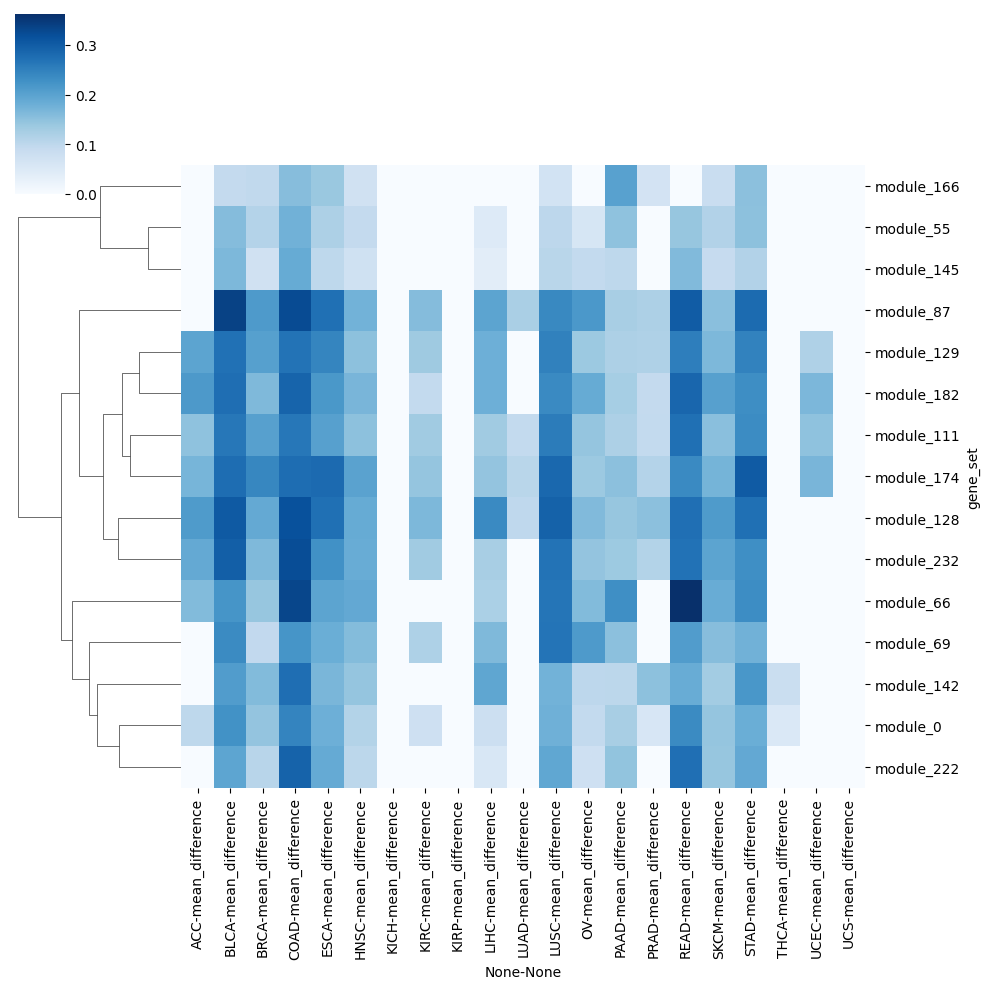

In [32]:
plt.rcParams["figure.figsize"] = (5,5)
g=sns.clustermap(revtestresdf2.loc['IE/F'].loc[iefind].fillna(0),cmap='Blues',col_cluster=False)
#g.ax_row_dendrogram.set_visible(False)
g.figure.savefig(figpath+"ecmsubtypeief_fig4.svg",dpi=300,bbox_inches = "tight")

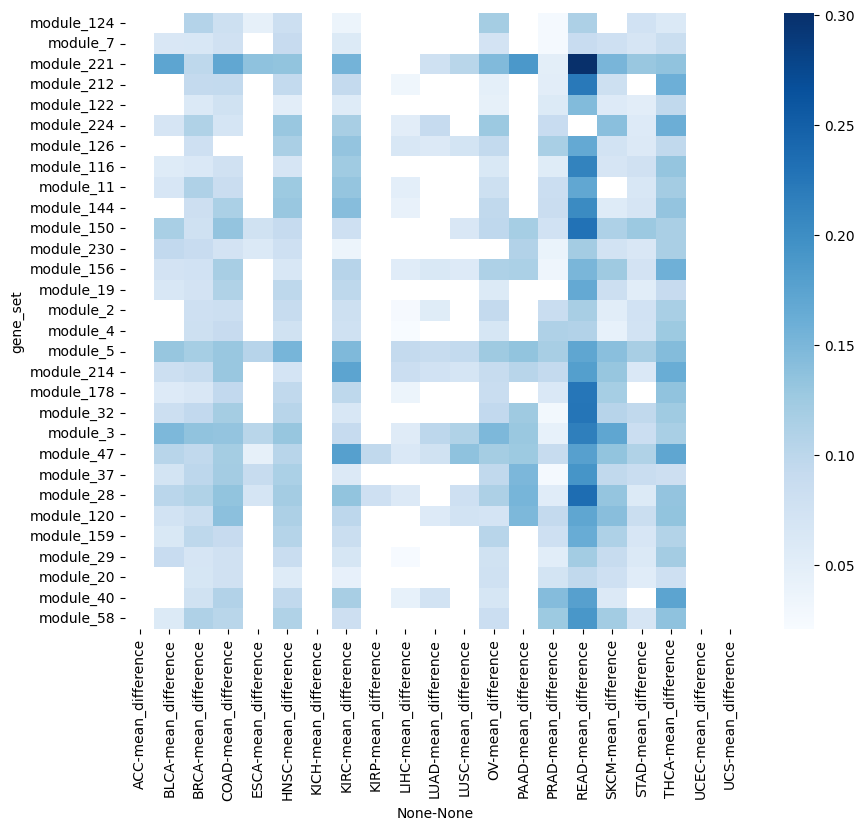

In [37]:
plt.rcParams["figure.figsize"] = (10,8)
g=sns.heatmap(revtestresdf2.loc['F'].loc[list(set(fbind)-set(iefind))],cmap='Blues')
g.figure.savefig(figpath+"ecmsubtypeF_sfig4.svg",dpi=300,bbox_inches = "tight")

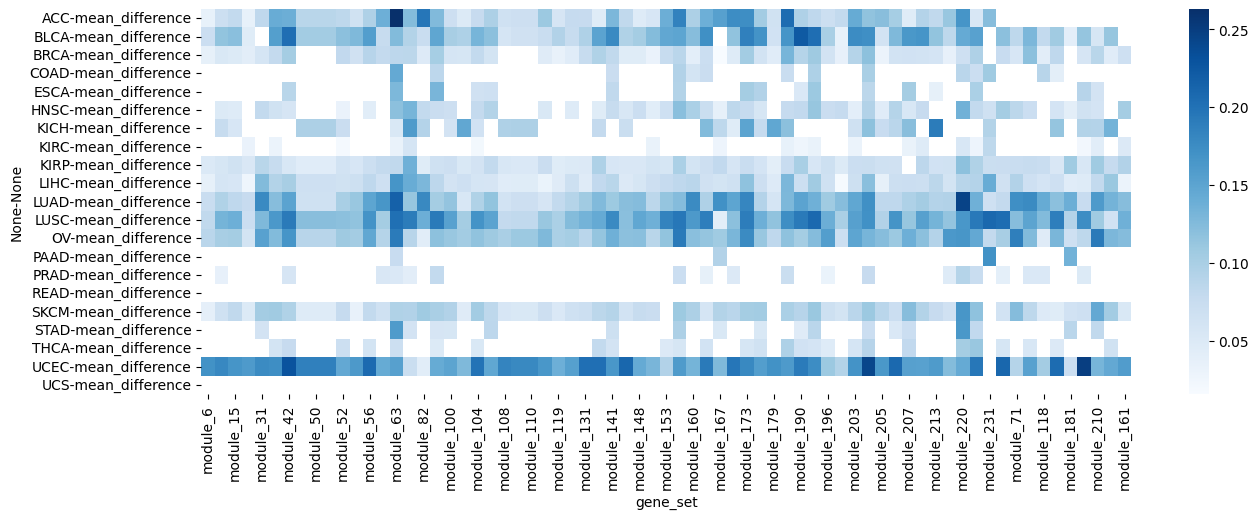

In [35]:
plt.rcParams["figure.figsize"] = (15,5)
g=sns.heatmap(revtestresdf2.loc['D'].loc[dind].transpose(),cmap='Blues')
g.figure.savefig(figpath+"ecmsubtypeD_sfig4.svg",dpi=300,bbox_inches = "tight")

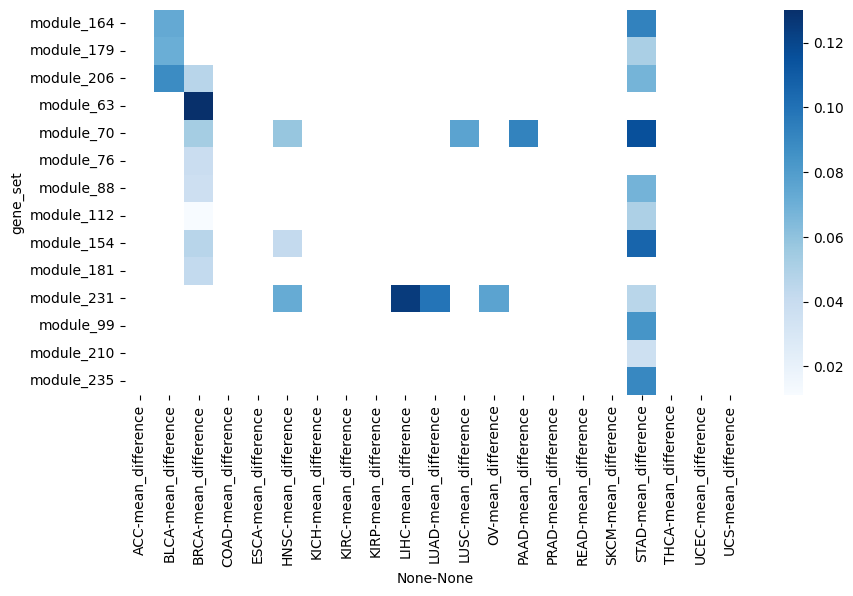

In [38]:
plt.rcParams["figure.figsize"] = (10,5)
g=sns.heatmap(revtestresdf2.loc['IE'],cmap='Blues')
g.figure.savefig(figpath+"ecmsubtypeIE_sfig4.svg",dpi=300,bbox_inches = "tight")

In [39]:
subtype_grp=ecm_subtypes.dropna(subset=["TCGA Subtype"]).reset_index().groupby(["TCGA_project","TCGA Subtype"]).agg({"sampid":list})

In [43]:
subtype_grp.index

MultiIndex([( 'ACC',             'ACC.CIMP-high'),
            ( 'ACC',     'ACC.CIMP-intermediate'),
            ( 'ACC',              'ACC.CIMP-low'),
            ('BLCA',                    'BLCA.1'),
            ('BLCA',                    'BLCA.2'),
            ('BLCA',                    'BLCA.3'),
            ('BLCA',                    'BLCA.4'),
            ('BRCA',                'BRCA.Basal'),
            ('BRCA',                 'BRCA.Her2'),
            ('BRCA',                 'BRCA.LumA'),
            ('BRCA',                 'BRCA.LumB'),
            ('BRCA',               'BRCA.Normal'),
            ('COAD',                    'GI.CIN'),
            ('COAD',                     'GI.GS'),
            ('COAD',                 'GI.HM-SNV'),
            ('COAD',               'GI.HM-indel'),
            ('ESCA',                    'GI.CIN'),
            ('ESCA',                   'GI.ESCC'),
            ('ESCA',                     'GI.GS'),
            ('ESCA',           

In [38]:
ecm_subtypes.loc['TCGA.A1.A0SB']

TCGA_project                               BRCA
HISTOLOGICAL_SUBTYPE                       BRCA
Gender                                        F
Age                                        70.0
P_stage                                    I/II
C_stage                                     NaN
MFP                                           D
Immune Subtype                               C1
TCGA Subtype                        BRCA.Normal
OS                                        259.0
OS_FLAG                                     0.0
PFS                                       259.0
PFS_Flag                                    0.0
ips_ctla4_neg_pd1_neg                       8.0
ips_ctla4_neg_pd1_pos                       5.0
ips_ctla4_pos_pd1_neg                       7.0
ips_ctla4_pos_pd1_pos                       5.0
Purity                                   0.9328
TMB                                    0.419783
BCR Evenness                                NaN
BCR Shannon                             

In [21]:
fulldf=pd.merge(rev_realsupmod_ecm,ecm_subtypes ,left_on="level_3",right_on="sampid",how="inner").set_index(["level_0","level_1","level_2","level_3"])

In [22]:
fulldf

module_0  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.296390   
                                                                     TCGA.OR.A5LT -0.292950   
                                                                     TCGA.OR.A5LN -0.194907   
                                                                     TCGA.OR.A5JB -0.261609   
                                                                     TCGA.OR.A5LG -0.298180   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3  0.299556   
                                                                     TCGA.PG.A7D5  0.210483   
                                                                     TCGA.B5.A11R -0.278552   
                                                                     TCGA.B5.A3S1  0.153603   
                                                                     TCGA.FI.A2EY  0.205801   

                                                                                   module_2  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9  0.154004   
                                                                     TCGA.OR.A5LT -0.317137   
                                                                     TCGA.OR.A5LN -0.302740   
                                                                     TCGA.OR.A5JB -0.328005   
                                                                     TCGA.OR.A5LG -0.330853   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3 -0.180599   
                                                                     TCGA.PG.A7D5  0.203514   
                                                                     TCGA.B5.A11R -0.202529   
                                                                     TCGA.B5.A3S1  0.172141   
                                                                     TCGA.FI.A2EY -0.247302   

                                                                                   module_3  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.339593   
                                                                     TCGA.OR.A5LT -0.299898   
                                                                     TCGA.OR.A5LN -0.267496   
                                                                     TCGA.OR.A5JB -0.334533   
                                                                     TCGA.OR.A5LG -0.335138   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3  0.292388   
                                                                     TCGA.PG.A7D5  0.190633   
                                                                     TCGA.B5.A11R -0.266400   
                                                                     TCGA.B5.A3S1  0.152114   
                                                                     TCGA.FI.A2EY  0.226952   

                                                                                   module_4  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.169004   
                                                                     TCGA.OR.A5LT -0.28600

In [23]:
y=fulldf["MFP"].copy()

In [24]:
y.index.get_level_values(0).unique()

Index(['TCGA-ACC', 'TCGA-BLCA', 'TCGA-BRCA', 'TCGA-COAD', 'TCGA-ESCA',
       'TCGA-HNSC', 'TCGA-KICH', 'TCGA-KIRC', 'TCGA-KIRP', 'TCGA-LIHC',
       'TCGA-LUAD', 'TCGA-LUSC', 'TCGA-OV', 'TCGA-PAAD', 'TCGA-PRAD',
       'TCGA-READ', 'TCGA-SKCM1', 'TCGA-SKCM2', 'TCGA-STAD', 'TCGA-THCA',
       'TCGA-UCS', 'TCGA-UCEC'],
      dtype='object', name='level_0')

In [26]:
d1={"D":0,"F":1,"IE":2,"IE/F":3}
d2={"F":0,"IE":1,"IE/F":2,"D":3}
d3={"F":3,"IE":0,"IE/F":1,"D":2}
d4={"F":2,"IE":3,"IE/F":0,"D":1}
d1_inv={}
for k in d1:
    d1_inv["MFP = "+str(d1[k]-1)]=k
d2_inv={}
for k in d2:
    d2_inv["MFP = "+str(d2[k]-1)]=k
d3_inv={}
for k in d3:
    d3_inv["MFP = "+str(d3[k]-1)]=k
d4_inv={}
for k in d4:
    d4_inv["MFP = "+str(d4[k]-1)]=k

In [27]:
y1=y.map(d1)
y2=y.map(d2)
y3=y.map(d3)
y4=y.map(d4)

In [174]:
y4

level_0    level_1  level_2                                                          level_3     
TCGA-ACC   PT       Adrenocortical Cancer_Adrenal gland_Primary Tumor                TCGA.PK.A5H9    0
                                                                                     TCGA.OR.A5LT    1
                                                                                     TCGA.OR.A5LN    3
                                                                                     TCGA.OR.A5JB    3
                                                                                     TCGA.OR.A5LG    0
                                                                                                    ..
TCGA-UCEC  PT       Uterine Corpus Endometrioid Carcinoma_Endometrium_Primary Tumor  TCGA.DI.A1C3    0
                                                                                     TCGA.PG.A7D5    1
                                                                              

In [142]:
y.cat.codes

level_0    level_1  level_2                                                          level_3     
TCGA-ACC   PT       Adrenocortical Cancer_Adrenal gland_Primary Tumor                TCGA.PK.A5H9    3
                                                                                     TCGA.OR.A5LT    0
                                                                                     TCGA.OR.A5LN    2
                                                                                     TCGA.OR.A5JB    2
                                                                                     TCGA.OR.A5LG    3
                                                                                                    ..
TCGA-UCEC  PT       Uterine Corpus Endometrioid Carcinoma_Endometrium_Primary Tumor  TCGA.DI.A1C3    3
                                                                                     TCGA.PG.A7D5    0
                                                                              

In [28]:
x=fulldf.loc[:,fulldf.columns.str.startswith("module")]

In [29]:
x.loc["TCGA-BRCA"]

module_0  \
level_1 level_2                                        level_3                  
PT      Breast Invasive Carcinoma_Breast_Primary Tumor TCGA.C8.A1HL  0.142127   
                                                       TCGA.EW.A2FS -0.093097   
                                                       TCGA.B6.A402 -0.201951   
                                                       TCGA.A2.A3XX  0.176467   
                                                       TCGA.Z7.A8R5 -0.174507   
...                                                                       ...   
                                                       TCGA.5T.A9QA -0.408007   
                                                       TCGA.AN.A0XT -0.189007   
                                                       TCGA.A2.A0YK  0.268468   
                                                       TCGA.A8.A09K -0.379273   
                                                       TCGA.A2.A1FV -0.191476   

                                                                     module_2  \
level_1 level_2                                        level_3                  
PT      Breast Invasive Carcinoma_Breast_Primary Tumor TCGA.C8.A1HL  0.187481   
                                                       TCGA.EW.A2FS -0.194639   
                                                       TCGA.B6.A402 -0.147254   
                                                       TCGA.A2.A3XX -0.173155   
                                                       TCGA.Z7.A8R5 -0.280959   
...                                                                       ...   
                                                       TCGA.5T.A9QA -0.279892   
                                                       TCGA.AN.A0XT  0.220628   
                                                       TCGA.A2.A0YK  0.341082   
                                                       TCGA.A8.A09K  0.262423   
                                                       TCGA.A2.A1FV  0.231314   

                                                                     module_3  \
level_1 level_2                                        level_3                  
PT      Breast Invasive Carcinoma_Breast_Primary Tumor TCGA.C8.A1HL  0.163976   
                                                       TCGA.EW.A2FS -0.126369   
                                                       TCGA.B6.A402 -0.154580   
                                                       TCGA.A2.A3XX  0.239912   
                                                       TCGA.Z7.A8R5 -0.297921   
...                                                                       ...   
                                                       TCGA.5T.A9QA -0.328686   
                                                       TCGA.AN.A0XT  0.126830   
                                                       TCGA.A2.A0YK  0.238565   
                                                       TCGA.A8.A09K -0.227459   
                                                       TCGA.A2.A1FV -0.134611   

                                                                     module_4  \
level_1 level_2                                        level_3                  
PT      Breast Invasive Carcinoma_Breast_Primary Tumor TCGA.C8.A1HL  0.183810   
                                                       TCGA.EW.A2FS -0.129327   
                                                       TCGA.B6.A402 -0.158963   
                                                       TCGA.A2.A3XX -0.179127   
                                                       TCGA.Z7.A8R5 -0.293039   
...                                                                       ...   
                                                       TCGA.5T.A9QA -0.253289   
                                                       TCGA.AN.A0XT  0.225474   
                                                       TCGA.A2.A0YK  0.310597   
                

In [30]:
# test classification dataset
from collections import Counter
print(x.shape, y.shape)
print(Counter(y))

(7438, 149) (7438,)
Counter({'D': 2875, 'IE': 1784, 'F': 1599, 'IE/F': 1180})


In [31]:
dat=pd.concat([x,y],axis=1,join='inner')

In [32]:
y.loc["TCGA-BRCA"]

level_1  level_2                                         level_3     
PT       Breast Invasive Carcinoma_Breast_Primary Tumor  TCGA.C8.A1HL       D
                                                         TCGA.EW.A2FS    IE/F
                                                         TCGA.B6.A402       D
                                                         TCGA.A2.A3XX      IE
                                                         TCGA.Z7.A8R5    IE/F
                                                                         ... 
                                                         TCGA.5T.A9QA       D
                                                         TCGA.AN.A0XT       D
                                                         TCGA.A2.A0YK    IE/F
                                                         TCGA.A8.A09K      IE
                                                         TCGA.A2.A1FV       D
Name: MFP, Length: 1070, dtype: object

In [33]:
import statsmodels.api as sm 
import statsmodels.formula.api as smf

In [34]:
dat

module_0  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.296390   
                                                                     TCGA.OR.A5LT -0.292950   
                                                                     TCGA.OR.A5LN -0.194907   
                                                                     TCGA.OR.A5JB -0.261609   
                                                                     TCGA.OR.A5LG -0.298180   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3  0.299556   
                                                                     TCGA.PG.A7D5  0.210483   
                                                                     TCGA.B5.A11R -0.278552   
                                                                     TCGA.B5.A3S1  0.153603   
                                                                     TCGA.FI.A2EY  0.205801   

                                                                                   module_2  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9  0.154004   
                                                                     TCGA.OR.A5LT -0.317137   
                                                                     TCGA.OR.A5LN -0.302740   
                                                                     TCGA.OR.A5JB -0.328005   
                                                                     TCGA.OR.A5LG -0.330853   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3 -0.180599   
                                                                     TCGA.PG.A7D5  0.203514   
                                                                     TCGA.B5.A11R -0.202529   
                                                                     TCGA.B5.A3S1  0.172141   
                                                                     TCGA.FI.A2EY -0.247302   

                                                                                   module_3  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.339593   
                                                                     TCGA.OR.A5LT -0.299898   
                                                                     TCGA.OR.A5LN -0.267496   
                                                                     TCGA.OR.A5JB -0.334533   
                                                                     TCGA.OR.A5LG -0.335138   
...                                                                                     ...   
TCGA-UCEC PT      Uterine Corpus Endometrioid Carcinoma_Endometri... TCGA.DI.A1C3  0.292388   
                                                                     TCGA.PG.A7D5  0.190633   
                                                                     TCGA.B5.A11R -0.266400   
                                                                     TCGA.B5.A3S1  0.152114   
                                                                     TCGA.FI.A2EY  0.226952   

                                                                                   module_4  \
level_0   level_1 level_2                                            level_3                  
TCGA-ACC  PT      Adrenocortical Cancer_Adrenal gland_Primary Tumor  TCGA.PK.A5H9 -0.169004   
                                                                     TCGA.OR.A5LT -0.28600

In [35]:
dat.loc["TCGA-BRCA"].droplevel([0,1],axis=0).dropna()

,module_0,module_2,module_3,module_4,module_5,module_6,module_7,module_10,module_11,module_13,...,module_222,module_223,module_224,module_227,module_228,module_230,module_231,module_232,module_235,MFP
level_3,,,,,,,,,,,,,,,,,,,,,
TCGA.C8.A1HL,0.142127,0.187481,0.163976,0.183810,-0.193193,0.161343,0.230685,0.161076,0.282138,-0.152878,...,0.272066,-0.287857,0.282968,0.193970,-0.216042,0.257204,-0.293385,0.354881,0.191414,D
TCGA.EW.A2FS,-0.093097,-0.194639,-0.126369,-0.129327,-0.210942,-0.181732,-0.132317,-0.224747,-0.146935,-0.172138,...,-0.302231,-0.216840,-0.236542,-0.310722,-0.167421,0.191106,-0.436938,-0.105094,-0.334696,IE/F
TCGA.B6.A402,-0.201951,-0.147254,-0.154580,-0.158963,-0.142987,0.135222,0.144716,0.183813,0.190497,0.154558,...,-0.265229,0.219573,-0.279465,0.191857,-0.241380,0.211729,0.296550,0.144285,-0.194013,D
TCGA.A2.A3XX,0.176467,-0.173155,0.239912,-0.179127,0.127670,-0.145266,0.149910,0.168395,-0.238688,0.217700,...,0.203684,0.272096,-0.266030,-0.213663,0.158065,-0.125956,0.280814,0.269144,0.237403,IE
TCGA.Z7.A8R5,-0.174507,-0.280959,-0.297921,-0.293039,-0.325724,-0.321628,-0.281125,-0.354790,-0.360676,-0.300530,...,-0.303093,-0.245993,-0.396102,-0.520309,-0.355933,-0.274347,0.371520,-0.168517,-0.325066,IE/F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA.5T.A9QA,-0.408007,-0.279892,-0.328686,-0.253289,-0.364851,-0.197386,-0.181885,-0.126934,-0.301070,-0.253475,...,-0.437015,0.294071,-0.220196,-0.190540,-0.292716,0.252031,0.471732,-0.394169,0.265627,D
TCGA.AN.A0XT,-0.189007,0.220628,0.126830,0.225474,0.207951,0.193945,0.188899,0.193138,0.215727,-0.147478,...,-0.095249,0.200588,0.187642,0.273663,0.232828,-0.289598,-0.536443,-0.200126,-0.348479,D
TCGA.A2.A0YK,0.268468,0.341082,0.238565,0.310597,0.294440,0.272672,0.273130,0.261712,0.314391,0.158432,...,0.480948,0.335679,0.476127,0.368234,0.295782,0.204158,-0.417433,0.382965,0.366986,IE/F


In [36]:
mod=sm.MNLogit(y1.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))
res1 = mod.fit(method="bfgs",maxiter=1000)
res1.summary()

Optimization terminated successfully.
         Current function value: 1.258718
         Iterations: 38
         Function evaluations: 39
         Gradient evaluations: 39


/tmp/ipykernel_57076/330048981.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  mod=sm.MNLogit(y1.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                    MFP   No. Observations:                 1070
Model:                        MNLogit   Df Residuals:                     1064
Method:                           MLE   Df Model:                            3
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.06009
Time:                        12:13:49   Log-Likelihood:                -1346.8
converged:                       True   LL-Null:                       -1432.9
Covariance Type:            nonrobust   LLR p-value:                 4.231e-37
==============================================================================
     MFP=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1315      0.335     -9.349      0.000      -3.788      -2.475
module_69      5.5545      0.652      8.522      0.000       4.277       6.832
------------------------------------------------------------------------------
     MFP=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1891      0.112     -1.687      0.092      -0.409       0.031
module_69     -0.6416      0.265     -2.424      0.015      -1.160      -0.123
------------------------------------------------------------------------------
     MFP=3       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7828      0.226     -7.900      0.000      -2.225      -1.341
module_69      2.4383      0.474      5.139      0.000       1.508       3.368
==============================================================================
"""

In [37]:
mod=sm.MNLogit(y2.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))
res2 = mod.fit(method="bfgs",maxiter=1000)
res2.summary()

Optimization terminated successfully.
         Current function value: 1.258718
         Iterations: 39
         Function evaluations: 40
         Gradient evaluations: 40


/tmp/ipykernel_57076/324838022.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  mod=sm.MNLogit(y2.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                    MFP   No. Observations:                 1070
Model:                        MNLogit   Df Residuals:                     1064
Method:                           MLE   Df Model:                            3
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.06009
Time:                        12:14:32   Log-Likelihood:                -1346.8
converged:                       True   LL-Null:                       -1432.9
Covariance Type:            nonrobust   LLR p-value:                 4.231e-37
==============================================================================
     MFP=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9421      0.338      8.710      0.000       2.280       3.604
module_69     -6.1957      0.664     -9.331      0.000      -7.497      -4.894
------------------------------------------------------------------------------
     MFP=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3486      0.374      3.604      0.000       0.615       2.082
module_69     -3.1162      0.725     -4.297      0.000      -4.537      -1.695
------------------------------------------------------------------------------
     MFP=3       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.1313      0.335      9.349      0.000       2.475       3.788
module_69     -5.5542      0.652     -8.522      0.000      -6.832      -4.277
==============================================================================
"""

In [38]:
mod=sm.MNLogit(y3.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))
res3 = mod.fit(method="bfgs",maxiter=1000)
res3.summary()

Optimization terminated successfully.
         Current function value: 1.258718
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37


/tmp/ipykernel_57076/2467898394.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  mod=sm.MNLogit(y3.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                    MFP   No. Observations:                 1070
Model:                        MNLogit   Df Residuals:                     1064
Method:                           MLE   Df Model:                            3
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.06009
Time:                        12:14:53   Log-Likelihood:                -1346.8
converged:                       True   LL-Null:                       -1432.9
Covariance Type:            nonrobust   LLR p-value:                 4.232e-37
==============================================================================
     MFP=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5943      0.228     -6.982      0.000      -2.042      -1.147
module_69      3.0811      0.486      6.335      0.000       2.128       4.034
------------------------------------------------------------------------------
     MFP=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1890      0.112      1.686      0.092      -0.031       0.409
module_69      0.6418      0.265      2.425      0.015       0.123       1.161
------------------------------------------------------------------------------
     MFP=3       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9419      0.338     -8.710      0.000      -3.604      -2.280
module_69      6.1953      0.664      9.331      0.000       4.894       7.497
==============================================================================
"""

In [39]:
mod=sm.MNLogit(y4.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))
res4 = mod.fit(method="bfgs",maxiter=1000)
res4.summary()

Optimization terminated successfully.
         Current function value: 1.258718
         Iterations: 38
         Function evaluations: 39
         Gradient evaluations: 39


/tmp/ipykernel_57076/1295660176.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  mod=sm.MNLogit(y4.loc["TCGA-BRCA"],sm.add_constant(x.loc["TCGA-BRCA","module_69"]))


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                    MFP   No. Observations:                 1070
Model:                        MNLogit   Df Residuals:                     1064
Method:                           MLE   Df Model:                            3
Date:                Wed, 09 Apr 2025   Pseudo R-squ.:                 0.06009
Time:                        12:15:00   Log-Likelihood:                -1346.8
converged:                       True   LL-Null:                       -1432.9
Covariance Type:            nonrobust   LLR p-value:                 4.232e-37
==============================================================================
     MFP=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7832      0.226      7.901      0.000       1.341       2.226
module_69     -2.4391      0.474     -5.141      0.000      -3.369      -1.509
------------------------------------------------------------------------------
     MFP=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3479      0.374     -3.602      0.000      -2.081      -0.614
module_69      3.1146      0.725      4.295      0.000       1.693       4.536
------------------------------------------------------------------------------
     MFP=3       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5941      0.228      6.981      0.000       1.147       2.042
module_69     -3.0807      0.486     -6.335      0.000      -4.034      -2.128
==============================================================================
"""

In [40]:
temp1=pd.concat(res1.summary2().tables[1:4])
temp1.columns=temp1.columns.to_series().replace(d1_inv)
temp2=pd.concat(res2.summary2().tables[1:4])
temp3=pd.concat(res3.summary2().tables[1:4])
temp4=pd.concat(res4.summary2().tables[1:4])
temp2.columns=temp2.columns.to_series().replace(d2_inv)
temp3.columns=temp3.columns.to_series().replace(d3_inv)
temp4.columns=temp4.columns.to_series().replace(d4_inv)

In [41]:
tr=pd.concat([temp1,temp2,temp3,temp4])

In [48]:
tr[tr["F"]==tr["F"]]['Coef.']['module_69'].mean()

4.954828980205587

In [49]:
tr[tr["IE"]==tr["IE"]]['Coef.']['module_69'].mean()

-3.3060092132798133

In [50]:
tr[tr["IE/F"]==tr["IE/F"]]['Coef.']['module_69'].mean()

0.8010679194445808

In [51]:
tr[tr["D"]==tr["D"]]['Coef.']['module_69'].mean()


-2.4504901555129517

In [279]:
res1.params

,0,1,2
const,-1.784254,-0.69502,-1.738543
module_68,4.515626,1.46958,3.784512


In [38]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score,cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
#oddratios={}
#cv = StratifiedKFold(10, random_state=10,shuffle=True)
#for proj in fulldf.index.get_level_values(0).unique():
#    models[] = LogisticRegression(multi_class='multinomial', solver='lbfgs',penalty='l2',max_iter=10000,class_weight='balanced').fit(x.loc[proj],y[proj])

In [39]:
n_scores = cross_val_score(model, x, y,cv=cv, n_jobs=2, verbose=0)

In [266]:
res1.summary2().tables[1:4]

[             MFP = 0     Coef.  Std.Err.         t         P>|t|    [0.025  \
 const          const -1.784254  0.178783 -9.980004  1.864585e-23 -2.134662   
 module_68  module_68  4.515626  0.546388  8.264498  1.402843e-16  3.444724   
 
              0.975]  
 const     -1.433846  
 module_68  5.586527  ,
              MFP = 1    Coef.  Std.Err.         t         P>|t|    [0.025  \
 const          const -0.69502  0.122339 -5.681113  1.338214e-08 -0.934799   
 module_68  module_68  1.46958  0.429708  3.419950  6.263272e-04  0.627368   
 
              0.975]  
 const     -0.455241  
 module_68  2.311792  ,
              MFP = 2     Coef.  Std.Err.         t         P>|t|    [0.025  \
 const          const -1.738543  0.178593 -9.734672  2.145092e-22 -2.088579   
 module_68  module_68  3.784512  0.557067  6.793637  1.093414e-11  2.692681   
 
              0.975]  
 const     -1.388508  
 module_68  4.876344  ]

In [35]:
import matplotlib.pyplot as plt
plt.boxplot(n_scores['test_score'], showmeans=True)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [28]:
addup=[]
for i in range(len(n_scores['estimator'])):
    addup.append(pd.DataFrame(n_scores['estimator'][i].coef_[0], index=x.columns))
pd.concat(addup,axis=1).mean(axis=1).sort_values(ascending=False)

module_220    0.979601
module_79     0.865648
module_204    0.859556
module_201    0.842523
module_228    0.763498
                ...   
module_162   -0.898894
module_36    -0.956142
module_64    -1.111441
module_76    -1.362298
module_96    -1.481166
Length: 237, dtype: float64

In [29]:
pd.DataFrame(n_scores['estimator'][0].coef_[0], index=x.columns).sort_values(by=0, ascending=True)[:10]

,0
module_96,-1.490142
module_76,-1.174067
module_162,-1.064763
module_64,-1.028240
module_36,-0.948393
module_170,-0.923489
module_153,-0.889846
module_194,-0.840135
module_14,-0.838060
module_229,-0.813450


In [30]:
pd.DataFrame(n_scores['estimator'][0].coef_[0], index=x.columns).sort_values(by=0, ascending=False)[:10]

,0
module_220,0.984955
module_204,0.963383
module_79,0.872026
module_151,0.860011
module_201,0.810665
module_105,0.747492
module_88,0.738489
module_228,0.737558
module_208,0.716669
module_230,0.664054


In [34]:
n_scores['estimator'][0].coef_[1]

array([ 2.69264946e-01,  5.04153461e-01, -3.26745438e-02,  4.18755513e-01,
        5.93620890e-02,  6.28585651e-02,  1.44102457e-01,  2.44901756e-02,
       -1.78209595e-01,  1.31355975e-01, -8.19753987e-02, -4.21898545e-01,
        9.85721735e-02,  1.10764063e-01,  2.51189742e-01, -2.20375369e-01,
       -1.07909877e-01,  4.99413520e-03, -2.54972821e-01,  2.86571050e-02,
        2.10004338e-01,  3.95334014e-02,  7.60090233e-02, -1.65611910e-01,
       -1.65611910e-01, -1.65611910e-01, -2.45385631e-01, -2.45385631e-01,
        1.42069224e-01,  1.62117803e-01,  2.63361207e-01,  2.07103249e-01,
        2.21850156e-01,  5.64509660e-02, -4.18684958e-02, -1.94126601e-02,
        1.43998406e-01,  2.03920659e-01,  2.70705447e-01,  1.74157220e-01,
        1.44395188e-01,  7.61478784e-02, -2.07470632e-01, -7.86179369e-01,
        2.20374062e-01,  2.70986715e-01,  2.42972818e-01,  2.62468913e-01,
        2.96808833e-03,  1.21681428e-01,  1.21681428e-01,  1.21681428e-01,
       -2.79680774e-01,  